# Clasificador de imagenes

In [26]:
import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

In [27]:
project_dir = Path("/workspaces/AG-Clasificador-de-imagenes")
original_dir = project_dir / "data" / "raw" / "dogs-vs-cats" / "train"
base_dir = project_dir / "data" / "split"
models_dir = project_dir / "models"

models_dir.mkdir(parents=True, exist_ok=True)

print("Ruta original:", original_dir)
print("¿Existe?", original_dir.exists())
print("Número de jpg:", len(list(original_dir.glob("*.jpg"))))

Ruta original: /workspaces/AG-Clasificador-de-imagenes/data/raw/dogs-vs-cats/train
¿Existe? True


Número de jpg: 25000


In [28]:
if base_dir.exists():
    shutil.rmtree(base_dir)
    print("Carpeta split eliminada")
else:
    print("La carpeta split no existía")

Carpeta split eliminada


In [29]:
files = [f.name for f in original_dir.glob("*.jpg")]

print("Número total de imágenes:", len(files))
print("Primeros 10 archivos:", files[:10])

Número total de imágenes: 25000
Primeros 10 archivos: ['cat.3431.jpg', 'dog.1033.jpg', 'cat.4787.jpg', 'cat.3444.jpg', 'dog.200.jpg', 'cat.3476.jpg', 'dog.3401.jpg', 'dog.4131.jpg', 'cat.2826.jpg', 'cat.205.jpg']


In [30]:
cat_files = [f for f in files if f.startswith("cat")]
dog_files = [f for f in files if f.startswith("dog")]

print("Número de imágenes de gatos:", len(cat_files))
print("Número de imágenes de perros:", len(dog_files))
print("Primeros 5 gatos:", cat_files[:5])
print("Primeros 5 perros:", dog_files[:5])

Número de imágenes de gatos: 12500
Número de imágenes de perros: 12500
Primeros 5 gatos: ['cat.3431.jpg', 'cat.4787.jpg', 'cat.3444.jpg', 'cat.3476.jpg', 'cat.2826.jpg']
Primeros 5 perros: ['dog.1033.jpg', 'dog.200.jpg', 'dog.3401.jpg', 'dog.4131.jpg', 'dog.7715.jpg']


In [31]:
train_cats = base_dir / "train" / "cats"
train_dogs = base_dir / "train" / "dogs"
test_cats = base_dir / "test" / "cats"
test_dogs = base_dir / "test" / "dogs"

for folder in [train_cats, train_dogs, test_cats, test_dogs]:
    folder.mkdir(parents=True, exist_ok=True)

print("Carpetas creadas correctamente")

Carpetas creadas correctamente


In [32]:
random.seed(42)
random.shuffle(cat_files)
random.shuffle(dog_files)

split_ratio = 0.8

cat_split = int(len(cat_files) * split_ratio)
dog_split = int(len(dog_files) * split_ratio)

train_cat_files = cat_files[:cat_split]
test_cat_files = cat_files[cat_split:]

train_dog_files = dog_files[:dog_split]
test_dog_files = dog_files[dog_split:]

print("Train cats:", len(train_cat_files))
print("Test cats:", len(test_cat_files))
print("Train dogs:", len(train_dog_files))
print("Test dogs:", len(test_dog_files))

Train cats: 10000
Test cats: 2500
Train dogs: 10000
Test dogs: 2500


In [33]:
def copy_files(file_list, source_dir, target_dir):
    copied = 0
    for file_name in file_list:
        src = source_dir / file_name
        dst = target_dir / file_name

        if src.exists() and not dst.exists():
            shutil.copy2(src, dst)
            copied += 1
    return copied

In [34]:
copied_train_cats = copy_files(train_cat_files, original_dir, train_cats)
copied_test_cats = copy_files(test_cat_files, original_dir, test_cats)
copied_train_dogs = copy_files(train_dog_files, original_dir, train_dogs)
copied_test_dogs = copy_files(test_dog_files, original_dir, test_dogs)

print("Copiados train cats:", copied_train_cats)
print("Copiados test cats:", copied_test_cats)
print("Copiados train dogs:", copied_train_dogs)
print("Copiados test dogs:", copied_test_dogs)

Copiados train cats: 10000
Copiados test cats: 2500
Copiados train dogs: 10000
Copiados test dogs: 2500


In [35]:
print("Train cats reales:", len(os.listdir(train_cats)))
print("Train dogs reales:", len(os.listdir(train_dogs)))
print("Test cats reales:", len(os.listdir(test_cats)))
print("Test dogs reales:", len(os.listdir(test_dogs)))

Train cats reales: 10000
Train dogs reales: 10000
Test cats reales: 2500
Test dogs reales: 2500


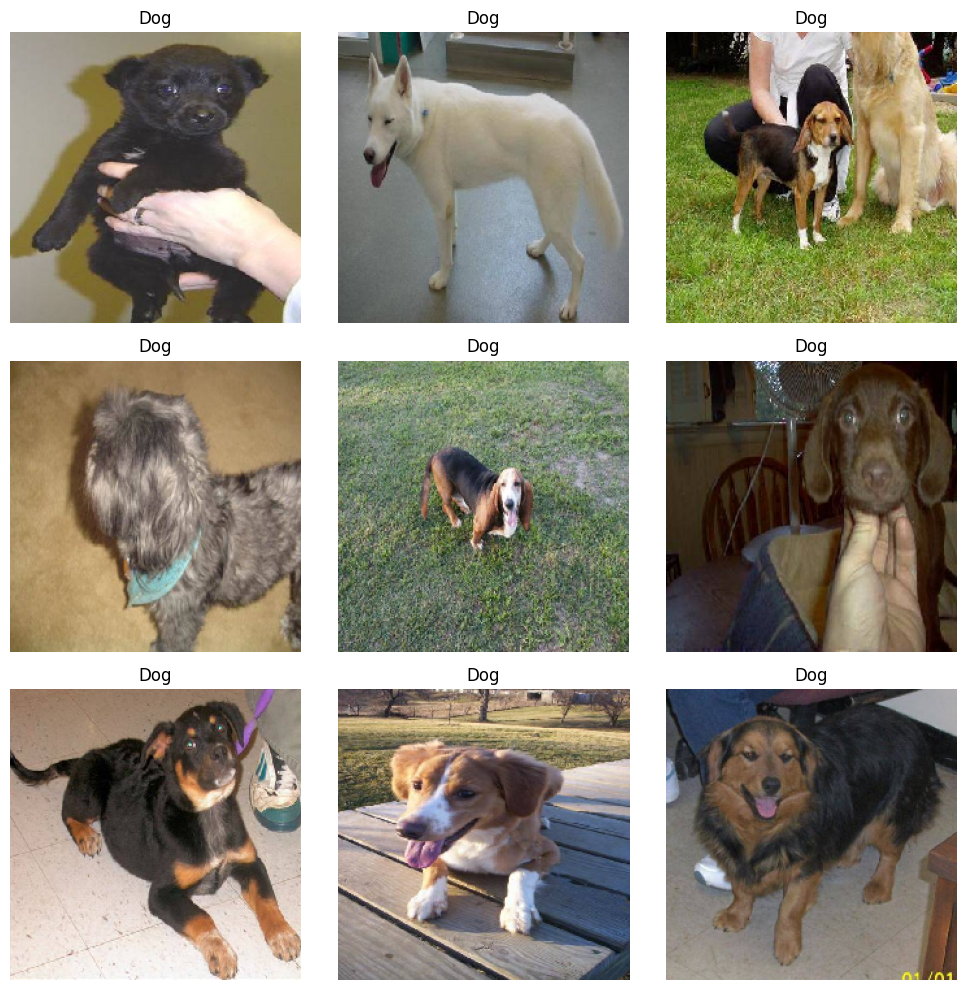

In [36]:
dog_images = os.listdir(train_dogs)[:9]

plt.figure(figsize=(10, 10))

for i, img_name in enumerate(dog_images):
    img_path = train_dogs / img_name
    img = load_img(img_path, target_size=(224, 224))

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title("Dog")

plt.tight_layout()
plt.show()

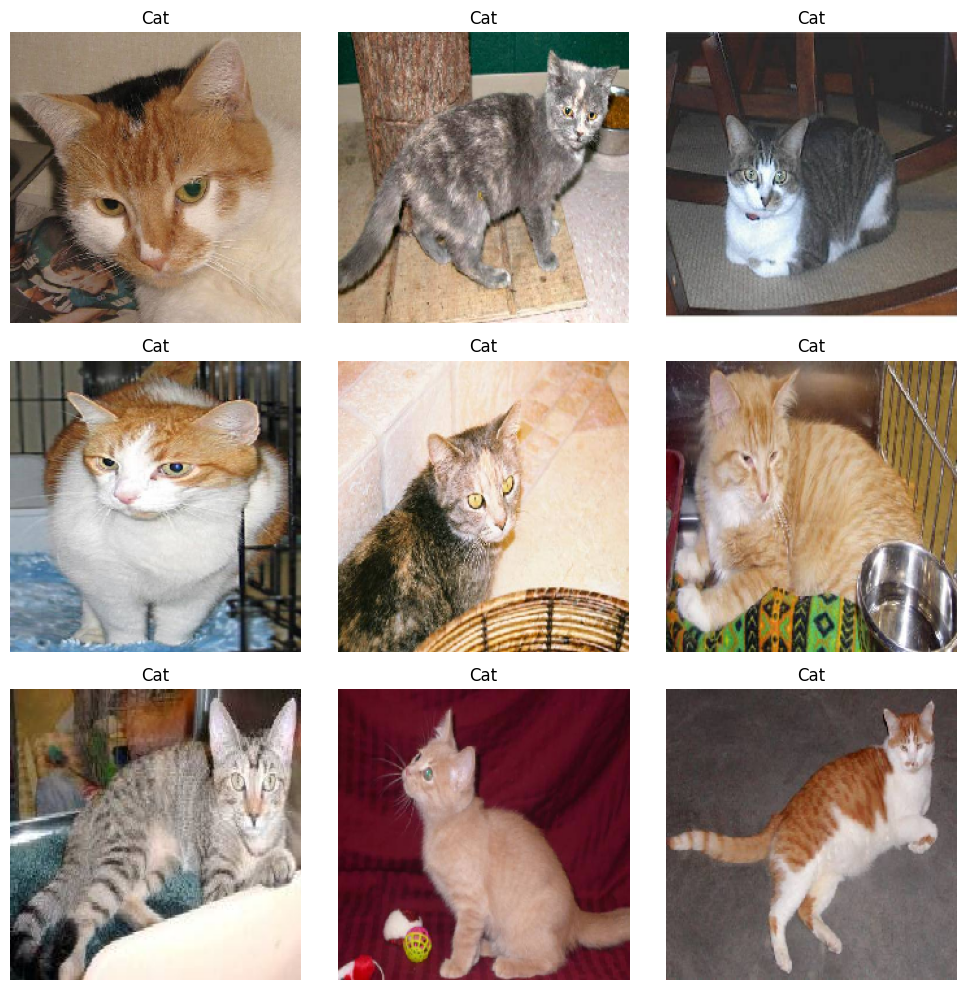

In [37]:
cat_images = os.listdir(train_cats)[:9]

plt.figure(figsize=(10, 10))

for i, img_name in enumerate(cat_images):
    img_path = train_cats / img_name
    img = load_img(img_path, target_size=(224, 224))

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title("Cat")

plt.tight_layout()
plt.show()

In [38]:
trdata = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

tsdata = ImageDataGenerator(
    rescale=1./255
)

In [39]:
train_generator = trdata.flow_from_directory(
    directory=str(base_dir / "train"),
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    subset="training"
)

Found 16000 images belonging to 2 classes.


In [40]:
train_generator = trdata.flow_from_directory(
    directory=str(base_dir / "train"),
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    subset="training"
)

Found 16000 images belonging to 2 classes.


In [41]:
val_generator = trdata.flow_from_directory(
    directory=str(base_dir / "train"),
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    subset="validation"
)

Found 4000 images belonging to 2 classes.


In [42]:
test_generator = tsdata.flow_from_directory(
    directory=str(base_dir / "test"),
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    shuffle=False
)

Found 5000 images belonging to 2 classes.


In [43]:
print(train_generator.class_indices)

{'cats': 0, 'dogs': 1}


In [44]:
model = Sequential()

model.add(Conv2D(32, (3, 3), activation="relu", input_shape=(224, 224, 3)))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, (3, 3), activation="relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(128, (3, 3), activation="relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())
model.add(Dense(128, activation="relu"))
model.add(Dropout(0.5))
model.add(Dense(1, activation="sigmoid"))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [45]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [46]:
trdata = ImageDataGenerator(rescale=1./255)
tsdata = ImageDataGenerator(rescale=1./255)

In [47]:
test_loss, test_acc = model.evaluate(test_generator)

print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

157/157 ━━━━━━━━━━━━━━━━━━━━ 56s 349ms/step - accuracy: 0.4998 - loss: 0.6937
Test loss: 0.6937161087989807
Test accuracy: 0.4997999966144562


In [48]:
checkpoint = ModelCheckpoint(
    filepath=str(models_dir / "best_cnn_model.keras"),
    monitor="accuracy",
    mode="max",
    save_best_only=True
)

In [49]:
predictions = model.predict(test_generator)
predicted_classes = (predictions > 0.5).astype(int).flatten()

print("Primeras 10 predicciones:", predicted_classes[:10])
print("Primeras 10 clases reales:", test_generator.classes[:10])

157/157 ━━━━━━━━━━━━━━━━━━━━ 52s 328ms/step
Primeras 10 predicciones: [1 1 1 1 1 1 1 1 1 1]
Primeras 10 clases reales: [0 0 0 0 0 0 0 0 0 0]


In [50]:
print("train samples:", train_generator.samples)
print("val samples:", val_generator.samples)
print("test samples:", test_generator.samples)

train samples: 16000
val samples: 4000
test samples: 5000


In [51]:
model.save(str(models_dir / "final_dogs_vs_cats_model.keras"))
print("Modelo guardado correctamente")

Modelo guardado correctamente
